In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.metrics import mutual_info_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_PATH = os.path.join("..","datasets","raw","Telco-Customer-Churn.csv")

In [3]:
telco = pd.read_csv(DATA_PATH)
print(len(telco))
telco.head().T

7043


,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [4]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# TotalCharges - converting dtype to numeric
telco.TotalCharges = pd.to_numeric(telco.TotalCharges, errors='coerce')
telco.TotalCharges = telco.TotalCharges.fillna(0)

In [6]:
# Normalizing column names
telco.columns = telco.columns.str.lower().str.replace(' ','_')
# list of categorical columns
string_columns = list(telco.dtypes[telco.dtypes=='object'].index)
# Normalizing categorical values
for col in string_columns:
    telco[col] = telco[col].str.lower().str.replace(' ','_')
    
# Target Variable - Converting dtype no numeric - binary
telco.churn = (telco.churn=='yes').astype('int')
# Senior Citizen
telco.seniorcitizen = telco.seniorcitizen.map({0:'no', 1:'yes'})

## Exploratory Data Analysis

In [7]:
# dataset lenght
len(telco)

7043

In [8]:
telco.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
monthlycharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
totalcharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80
churn,7043.0,0.265370,0.441561,0.00,0.00,0.00,1.00,1.00


In [9]:
# Target variable value count
churn = telco.churn.value_counts()
churn

0    5174
1    1869
Name: churn, dtype: int64

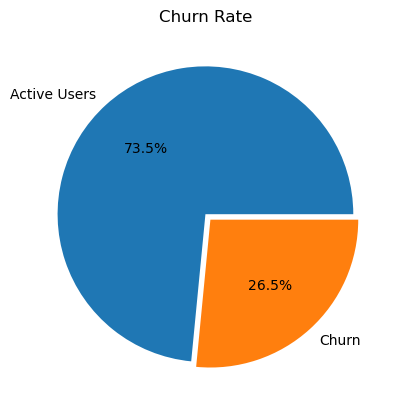

In [10]:
plt.pie(churn, explode=(0,0.05), labels=['Active Users', 'Churn'], autopct='%1.1f%%')
plt.title("Churn Rate")
plt.savefig(os.path.join("..","img","churn_pie_chart.png"))
plt.show()

In [11]:
global_mean = telco.churn.mean()
print("Global Mean: {}".format(round(global_mean,3)))

Global Mean: 0.265


In [12]:
numerical = ["tenure", "monthlycharges", "totalcharges"]
categorical = ["gender", "partner", "seniorcitizen","dependents", "phoneservice", "multiplelines", "internetservice",
"onlinesecurity", "onlinebackup", "deviceprotection", "techsupport", "streamingtv", "streamingmovies", "contract",
"paperlessbilling", "paymentmethod"]

<Figure size 640x480 with 0 Axes>

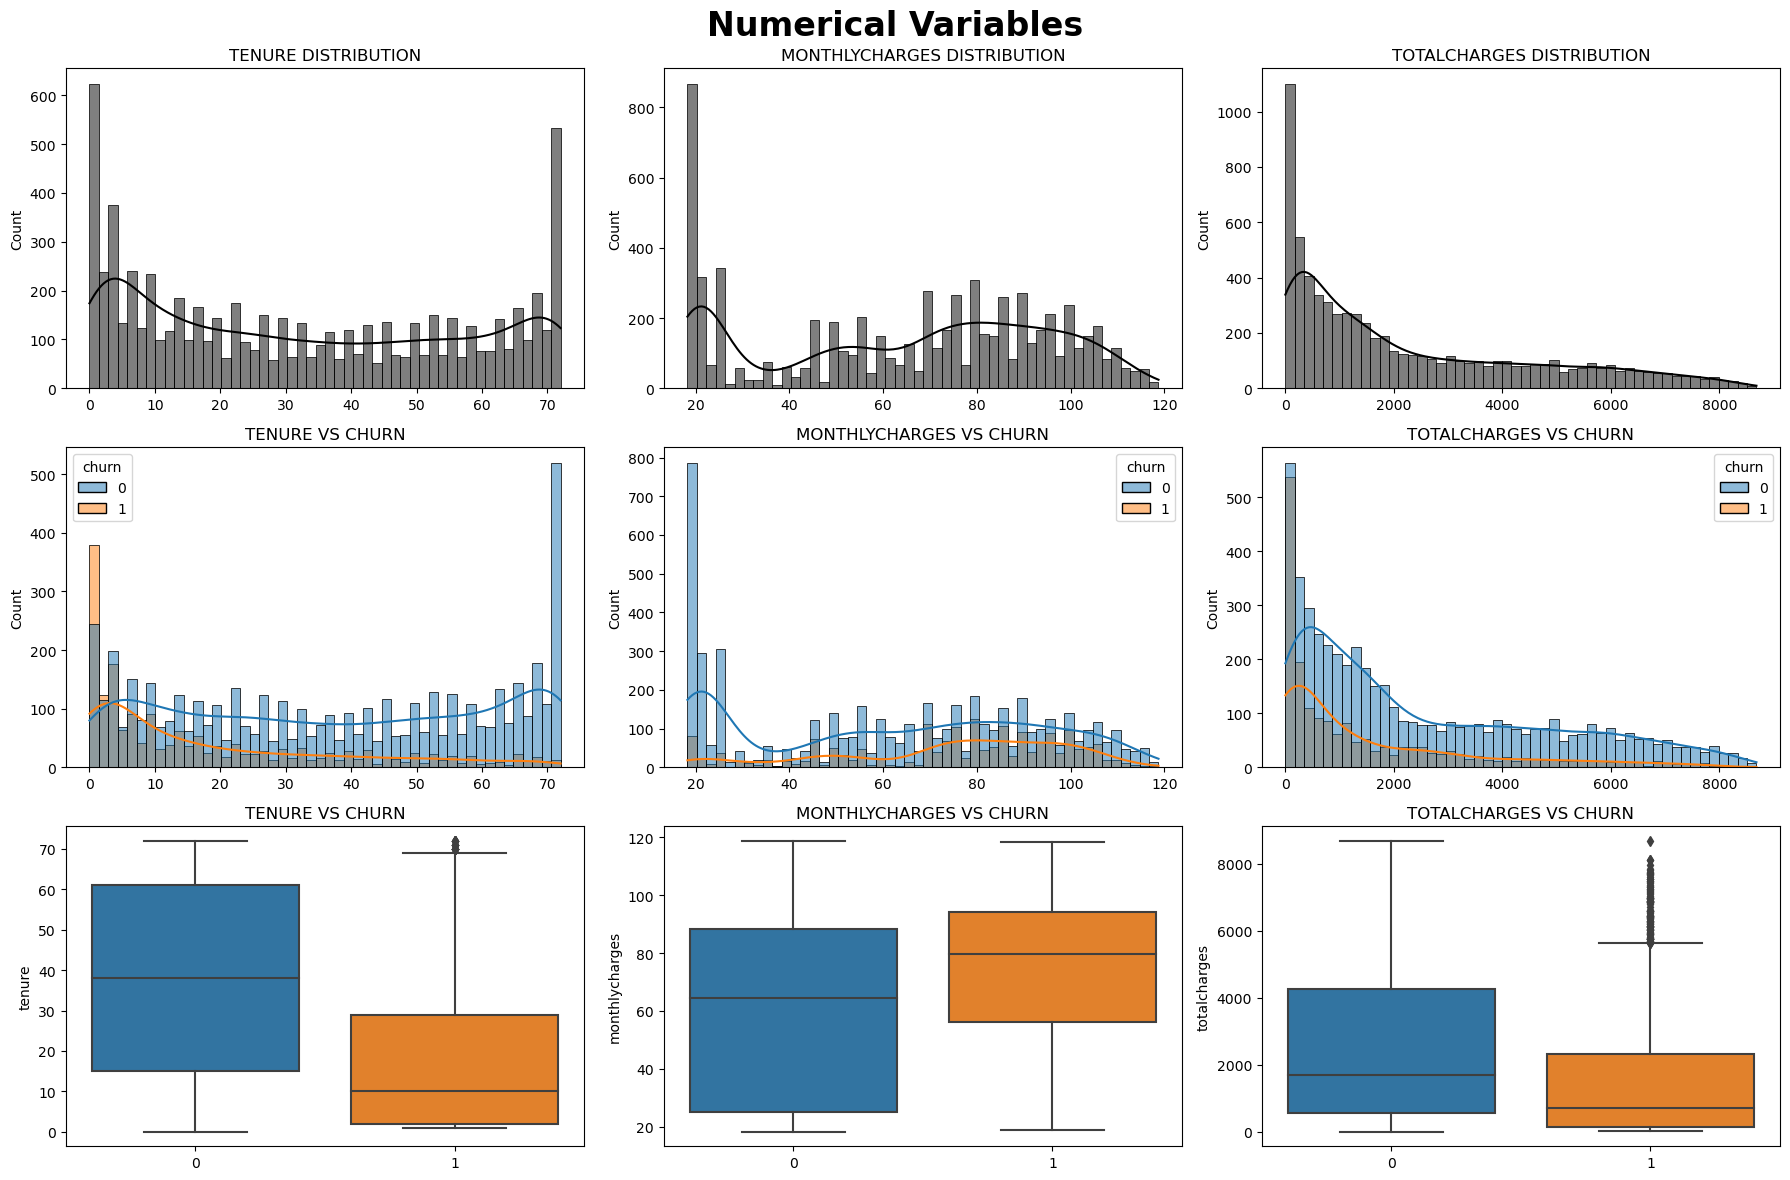

In [13]:
%run ../auxiliar_functions/numPlot.py

numPlot(telco, numerical)

<Figure size 640x480 with 0 Axes>

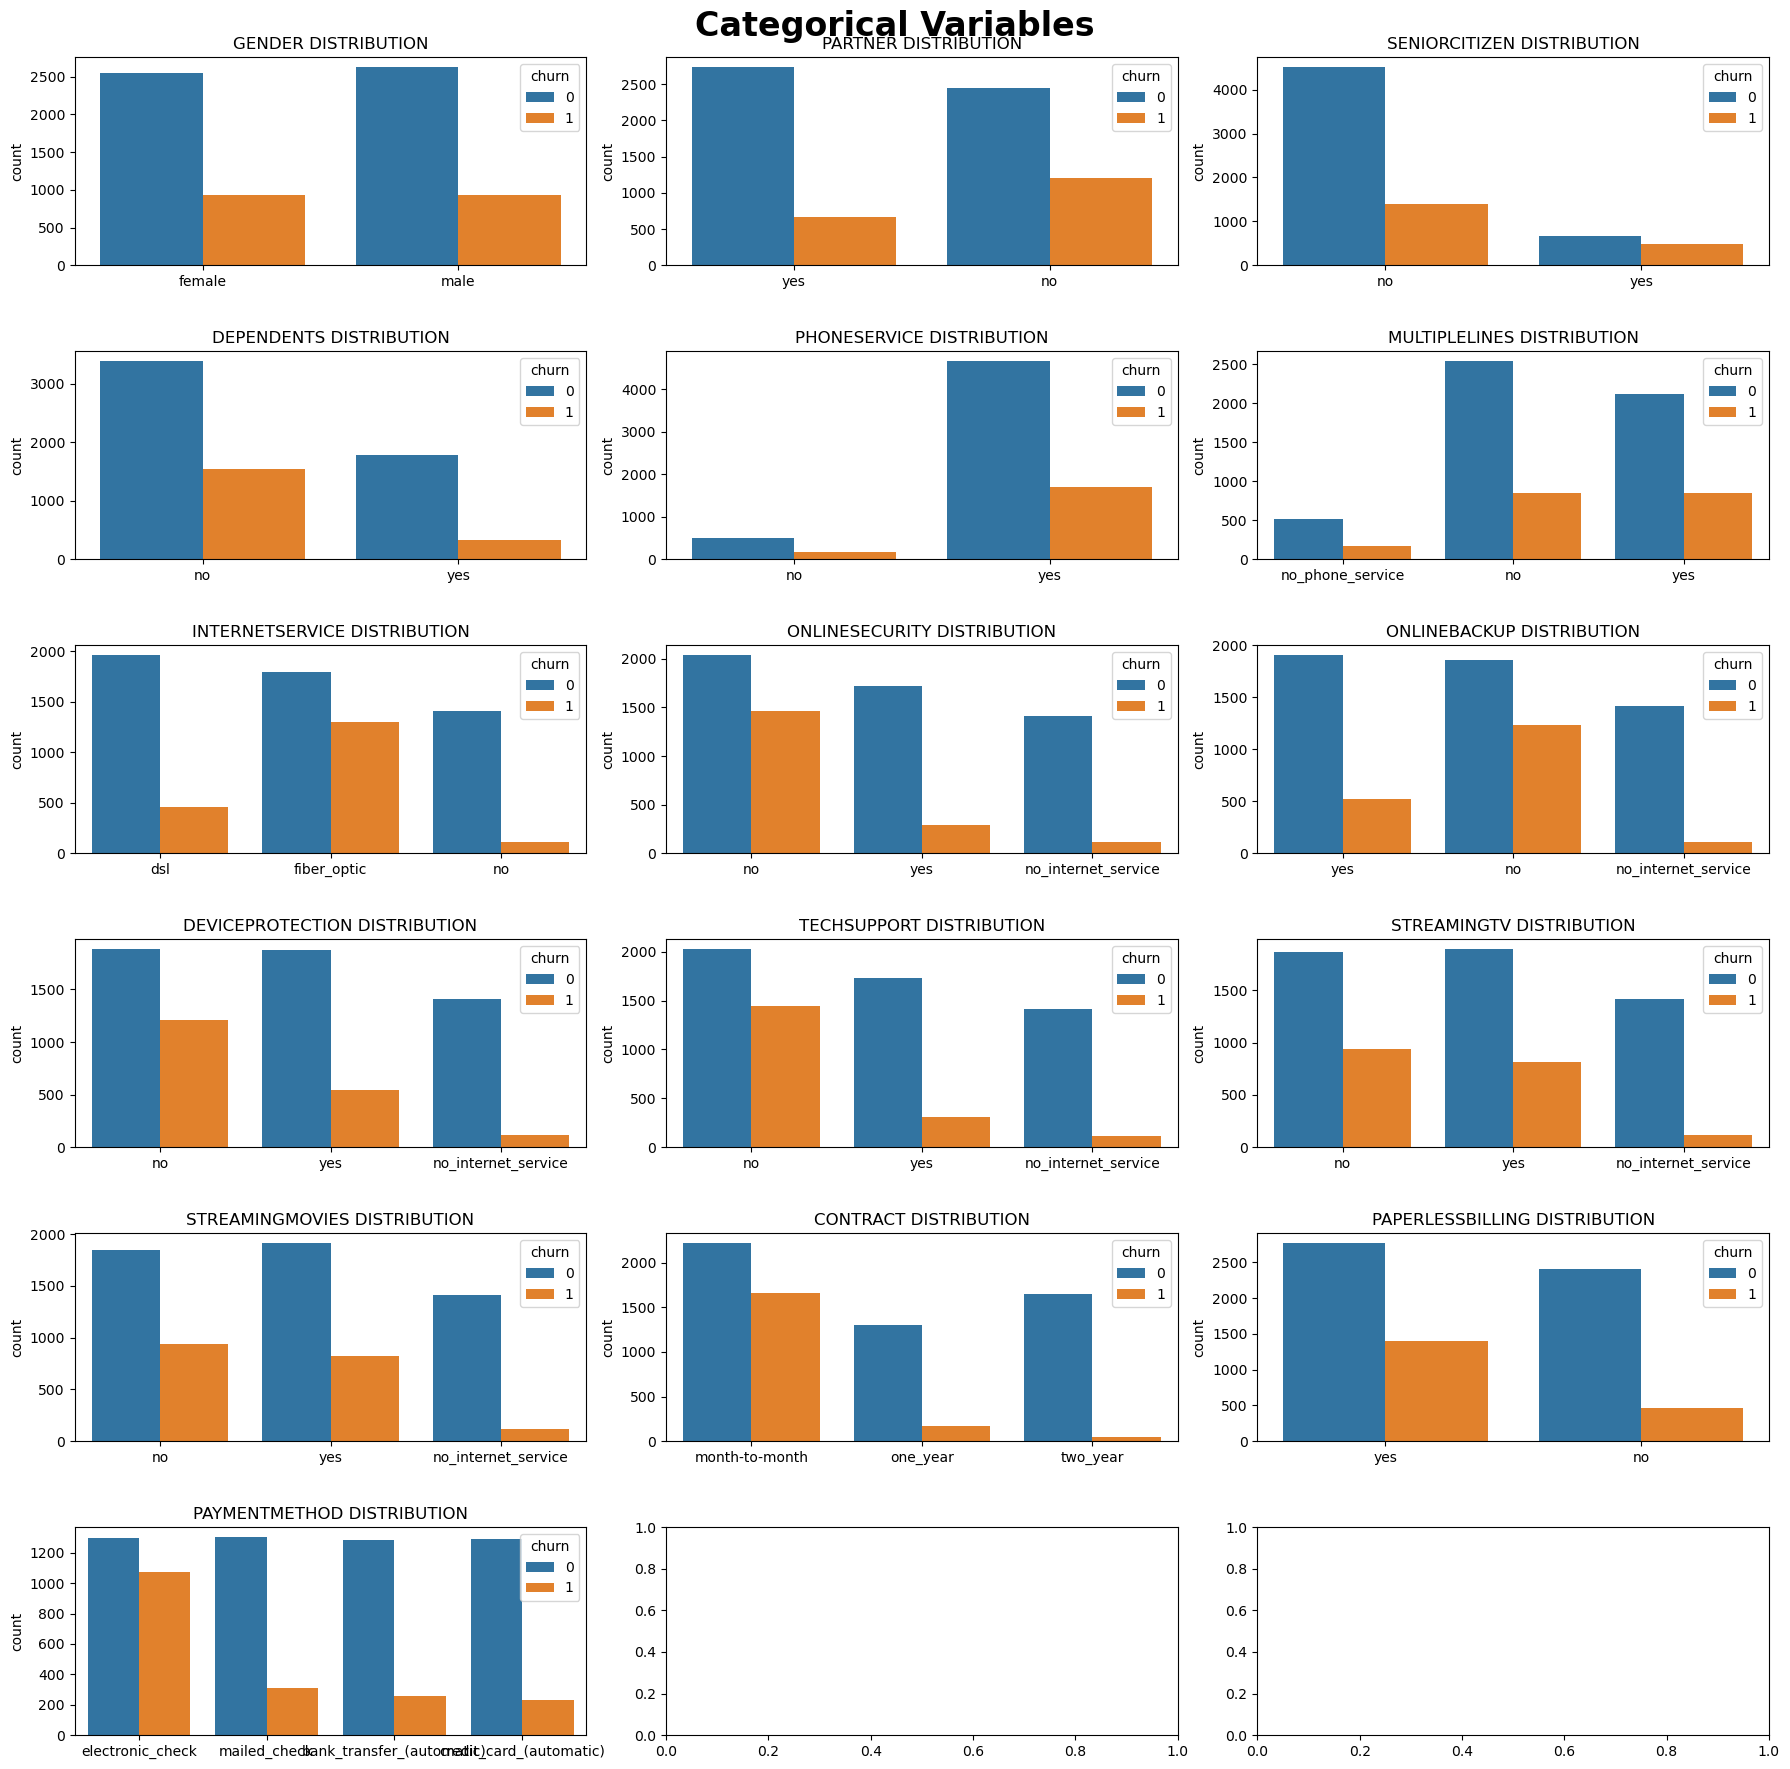

In [14]:
%run ../auxiliar_functions/catPlot.py
    
catPlot(telco, categorical)

### Correlation Coefficient

In [15]:
# Pearson correlation coefficient
telco[numerical].corrwith(telco.churn)

tenure           -0.352229
monthlycharges    0.193356
totalcharges     -0.198324
dtype: float64

### Mutual Information

In [16]:
# Mutual Information
def calculate_mi(series):
    return mutual_info_score(series, telco.churn)

df_mi = telco[categorical].apply(calculate_mi)
df_mi = df_mi.sort_values(ascending=False).to_frame(name='mi')
df_mi

,mi
contract,0.098453
onlinesecurity,0.064677
techsupport,0.063021
internetservice,0.055574
onlinebackup,0.046792
paymentmethod,0.044519
deviceprotection,0.043917
streamingmovies,0.032001
streamingtv,0.031908
paperlessbilling,0.019194


### Risk ratio

In [17]:
%run ../auxiliar_functions/risk_ratio.py
    
risk_ratio(telco, categorical)

,mean,diff,rate
gender,,,
female,0.269209,0.003839,1.014466
male,0.261603,-0.003766,0.985807


,mean,diff,rate
partner,,,
no,0.329580,0.064210,1.241964
yes,0.196649,-0.068721,0.741038


,mean,diff,rate
seniorcitizen,,,
no,0.236062,-0.029308,0.889557
yes,0.416813,0.151443,1.570686


,mean,diff,rate
dependents,,,
no,0.312791,0.047422,1.178700
yes,0.154502,-0.110868,0.582215


,mean,diff,rate
phoneservice,,,
no,0.249267,-0.016103,0.939319
yes,0.267096,0.001726,1.006506


...

,mean,diff,rate
streamingmovies,,,
no,0.336804,0.071434,1.269188
no_internet_service,0.074050,-0.191320,0.279044
yes,0.299414,0.034044,1.128291


,mean,diff,rate
contract,,,
month-to-month,0.427097,0.161727,1.609440
one_year,0.112695,-0.152675,0.424672
two_year,0.028319,-0.237051,0.106714


,mean,diff,rate
paperlessbilling,,,
no,0.163301,-0.102069,0.615371
yes,0.335651,0.070281,1.264842


,mean,diff,rate
paymentmethod,,,
bank_transfer_(automatic),0.167098,-0.098271,0.629681
credit_card_(automatic),0.152431,-0.112939,0.574410
electronic_check,0.452854,0.187484,1.706502
mailed_check,0.191067,-0.074303,0.720003


<Figure size 640x480 with 0 Axes>

## Weights

In [18]:
telco_dict = telco[categorical + numerical].to_dict(orient='records')

# DictVectorizer
dv = DictVectorizer(sparse=False)
telco_vec = dv.fit_transform(telco_dict)

# 
dv.get_feature_names_out()

array(['contract=month-to-month', 'contract=one_year',
       'contract=two_year', 'dependents=no', 'dependents=yes',
       'deviceprotection=no', 'deviceprotection=no_internet_service',
       'deviceprotection=yes', 'gender=female', 'gender=male',
       'internetservice=dsl', 'internetservice=fiber_optic',
       'internetservice=no', 'monthlycharges', 'multiplelines=no',
       'multiplelines=no_phone_service', 'multiplelines=yes',
       'onlinebackup=no', 'onlinebackup=no_internet_service',
       'onlinebackup=yes', 'onlinesecurity=no',
       'onlinesecurity=no_internet_service', 'onlinesecurity=yes',
       'paperlessbilling=no', 'paperlessbilling=yes', 'partner=no',
       'partner=yes', 'paymentmethod=bank_transfer_(automatic)',
       'paymentmethod=credit_card_(automatic)',
       'paymentmethod=electronic_check', 'paymentmethod=mailed_check',
       'phoneservice=no', 'phoneservice=yes', 'seniorcitizen=no',
       'seniorcitizen=yes', 'streamingmovies=no',
       'stream

In [19]:
# Logistic Regression
model = LogisticRegression(solver='liblinear', random_state=12)
model.fit(telco_vec, telco.churn)

LogisticRegression(random_state=12, solver='liblinear')

In [20]:
# Model Intercept
print("Model Intercept: {}".format(model.intercept_[0]))
# Weights
weights = dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))
weights = pd.Series(weights, index=weights.keys()).sort_values(ascending=False)
weights

Model Intercept: -0.11369808350532185


contract=month-to-month                    0.520
internetservice=fiber_optic                0.311
paymentmethod=electronic_check             0.258
onlinesecurity=no                          0.221
techsupport=no                             0.217
multiplelines=no_phone_service             0.131
phoneservice=no                            0.131
paperlessbilling=yes                       0.107
onlinebackup=no                            0.090
streamingmovies=yes                        0.080
streamingtv=yes                            0.076
seniorcitizen=yes                          0.031
deviceprotection=no                        0.021
dependents=no                              0.007
monthlycharges                             0.003
totalcharges                               0.000
multiplelines=yes                         -0.016
partner=yes                               -0.038
gender=female                             -0.042
deviceprotection=yes                      -0.045
tenure              